# cellAdmix Python standalone Xenium breast 5K example

This notebook mirrors the standalone Python pancreas example on a much larger 10x Xenium breast 5K dataset. It demonstrates the same core workflow at scale: construct a dataset object with curated cell-type annotations, fit molecular NMF factors, score admixture using the membrane image, inspect score evidence, render example cells, and write corrected counts.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from celladmix import CellAdmix, annotation_knn_purity, plot_spatial, read_annotation
from celladmix.plotting import plot_molecule_removal


## Inputs

Place the Xenium breast 5K bundle in a local folder named `data`.

Cell-type labels come from the curated annotation shipped with the example in `annotations/annotation.csv.gz` - the same labels the R membrane-scoring tutorial uses. Cells labeled `Ambiguous / low-quality` are dropped from the active annotation so they are not treated as a biological source or target class. If no curated labels exist for a dataset, `celladmix_batch.py --auto-annotate` can generate provisional cluster annotations to start from.

In [2]:
data_dir = Path("data")
output_dir = Path("out_python")
num_threads = 10

annotation_table = pd.read_csv(Path("annotations") / "annotation.csv.gz")
annotation_table = annotation_table[annotation_table["merged_annotation"] != "Ambiguous / low-quality"]
annotation = read_annotation(annotation_table, annotation_col="merged_annotation")
annotation.value_counts()

merged_annotation
Epithelial          166396
T / NK              118803
Myeloid              82470
B / plasma           25711
Endothelial          18016
Fibroblast / CAF     11279
Name: count, dtype: int64

`CellAdmix` records the Xenium bundle, output/cache location, active annotation, and default thread count. The constructor does not load all molecule rows into Python memory.


In [3]:
ds = CellAdmix(data_dir, output_dir=output_dir, annotation=annotation, num_threads=num_threads)
ds


CellAdmix(format='xenium', source='data', output_dir='out_python', annotation=6 labels, num_threads=10)

## Fit Factors

The fit stage constructs neighborhood count vectors, fits NMF factors, projects and smooths molecule assignments, and writes reusable run artifacts. With six annotated cell types the default annotation-derived rank is 8 factors.

The `invsqrt_kl` NMF variant is used because this membrane-stained dataset will be cleaned with membrane scoring, the recommended pairing (see [docs/benchmarks.md](../../docs/benchmarks.md)).

In [4]:
fit = ds.fit(nmf_variant="invsqrt_kl", verbose=True)
fit


Reusing cached run fit_rank8_invsqrt_kl (parameters match)


CellAdmixFit(run_path='out_python/runs/fit_rank8_invsqrt_kl', n_factors=8, n_cells=688099)

Top loading genes provide a first-pass interpretation of the factors.


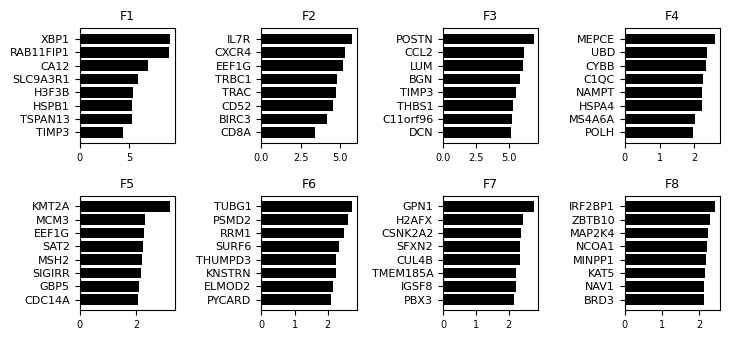

In [5]:
fit.plot_loadings(n_genes=8, ncol=4);

The stability plot summarizes multiseed NMF behavior. Points farther right are more abundant factors; higher points are more reproducible across random starts.


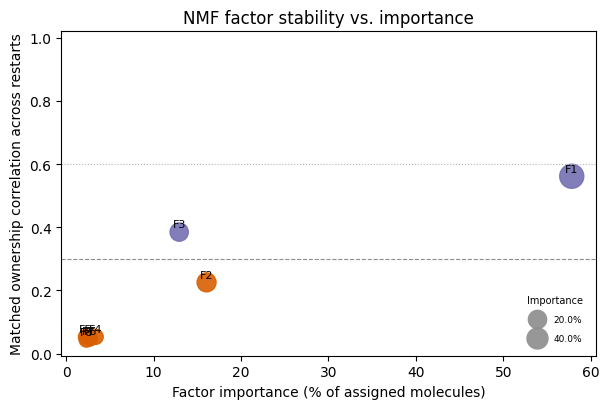

In [6]:
fit.plot_stability();


## Spatial Overview

For visual orientation, merge cell-level factor summaries with the annotation labels.


In [7]:
cell_factors = fit.cell_factors()
cell_spatial = cell_factors.merge(annotation_table[["cell_id", "merged_annotation"]], on="cell_id", how="left")
cell_spatial[["cell_id", "x", "y", "merged_annotation", "dominant_factor", "transcript_count"]].head()

,cell_id,x,y,merged_annotation,dominant_factor,transcript_count
0,imjonmkj-1,253.020111,12982.476562,NaN,2,13
1,imkckdbh-1,252.313660,12930.589844,NaN,3,20
2,imjoonig-1,241.917770,12923.190430,NaN,8,1
3,nlilhlfd-1,303.982422,3982.683105,NaN,3,2
4,nlmacoef-1,497.324615,5223.106445,T / NK,3,40


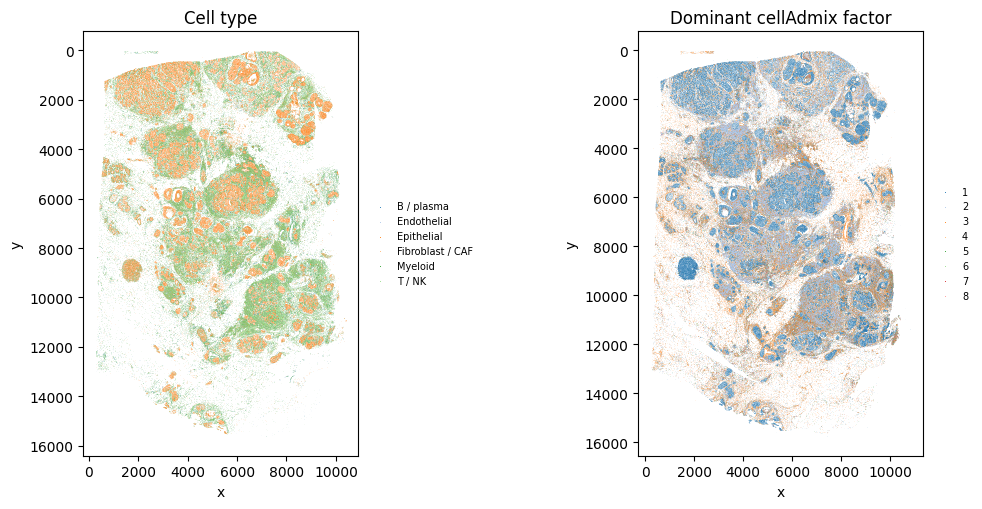

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
plot_spatial(cell_spatial, color_by="merged_annotation", title="Cell type", ax=axes[0], s=0.03)
plot_spatial(cell_spatial, color_by="dominant_factor", title="Dominant cellAdmix factor", ax=axes[1], s=0.03)
plt.show()

## Admixture Audit

Before correcting anything, the audit estimates each ordered cell-type
pair's admixture rate - the percent of the target type's molecules
that leaked in from the source - using only the spatial exposure
structure of the data. The same audit object verifies the correction
after cleanup.


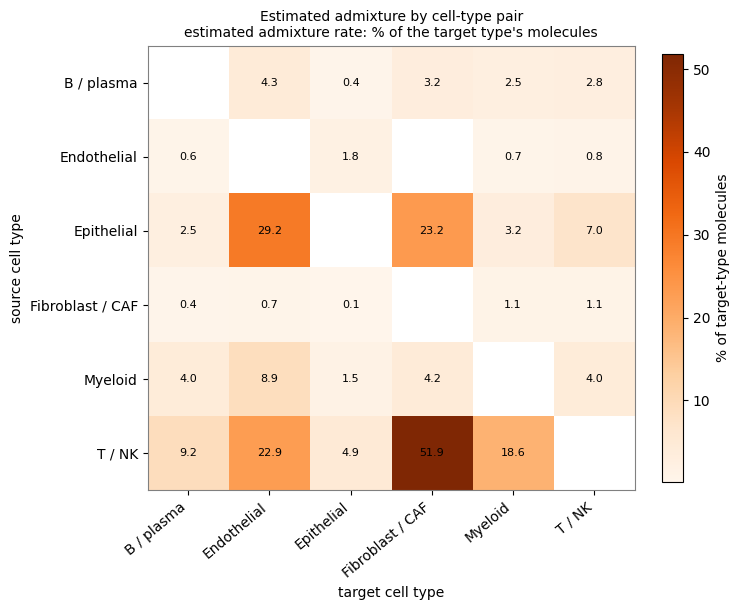

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 6.2))
audit = fit.audit_admixture()
audit.plot_map(ax=ax)
fig.tight_layout()

## Membrane Scoring

Membrane scoring asks whether target-cell molecules assigned to each factor are enriched along membrane-stain paths facing candidate source cells. This is the most expensive stage for this large dataset.


In [10]:
p_thresh = 0.1
membrane_score = fit.score_membrane(verbose=True)
membrane_score


[INFO 21:25:35 +63.216s] Starting membrane test: molecules=82144903, cells=688099 (0.000s)
[INFO 21:25:35 +63.217s] Opened membrane image: width=51265, height=74945 (0.000s)


[INFO 21:25:36 +65.094s] Prepared membrane data: cell_types=6, factors=8, active_cells=688099, typed_active_cells=422675 (1.877s)


[INFO 21:25:41 +69.729s] Discovered membrane candidates: pairs=14400 (4.634s)


[INFO 21:26:21 +110.098s] Scored membrane candidates: score_rows=46197 (40.369s)
[INFO 21:26:21 +110.105s] Summarized membrane scores: summaries=288 (0.008s)
[INFO 21:26:21 +110.106s] Finished membrane test: summaries=288 (46.889s)


CellAdmixScore(method='membrane', n_summary=288)

The heatmap summarizes source (`S`) and target correction (`*`) calls by factor and cell type.


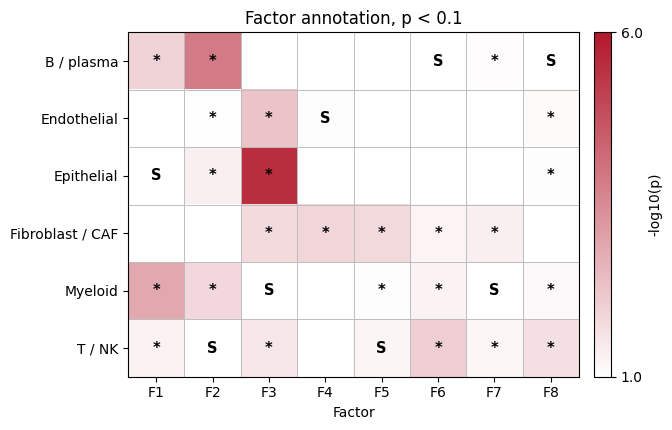

In [11]:
membrane_score.plot_heatmap(p_thresh=p_thresh, max_neg_log10=6);


The pair plots are shown for the most abundant factors. Columns are candidate source types, rows are candidate target types, the top row shows source evidence, and the main matrix shows signed admixture significance.


In [12]:
factor_cols = [col for col in cell_factors.columns if col.startswith("factor_") and col.endswith("_fraction")]
importance = (cell_factors[factor_cols].to_numpy(float) * cell_factors["transcript_count"].to_numpy(float)[:, None]).sum(axis=0)
top_factors = [int(factor_cols[i].split("_")[1]) for i in importance.argsort()[::-1][:6]]
top_factors


[1, 2, 3, 4, 6, 7]

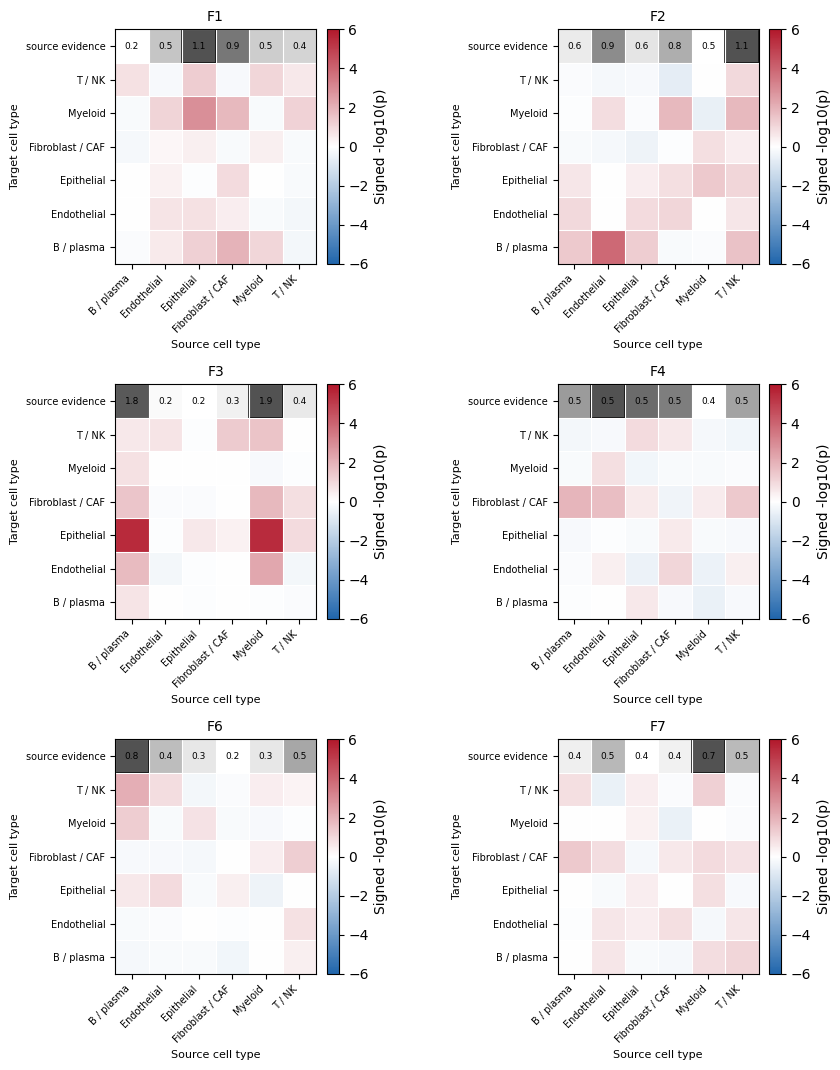

In [13]:
membrane_score.plot_pairs(factors=top_factors, p_thresh=p_thresh, max_abs_significance=6, ncol=2);


Correction rules are derived from factor annotations. Each rule removes molecules assigned to a factor from one target cell type; the source type is kept as the likely origin interpretation.


In [14]:
rules = membrane_score.rules(p_thresh=p_thresh)
rules[["factor", "source_cell_type", "target_cell_type", "p_value"]].head(20)


,factor,source_cell_type,target_cell_type,p_value
8,3,Myeloid,Epithelial,0.000003
3,2,T / NK,B / plasma,0.000140
1,1,Epithelial,Myeloid,0.001327
7,3,Myeloid,Endothelial,0.005121
16,6,B / plasma,T / NK,0.008560
0,1,Epithelial,B / plasma,0.011246
11,4,Endothelial,Fibroblast / CAF,0.012839
6,2,T / NK,Myeloid,0.014957
12,5,T / NK,Fibroblast / CAF,0.015490
9,3,Myeloid,Fibroblast / CAF,0.016462


## Example Cells

The example-cell overlays show local molecule context before cleanup. Blue molecules are native factors for the target cell type, red molecules are the selected top admixture factor, and orange molecules are other non-native factors. Outside-cell molecules use the same colors at lower emphasis.


In [15]:
score_annotation = membrane_score.annotation(p_thresh=p_thresh)
diagnostic_cell_types = rules["target_cell_type"].value_counts().head(2).index.tolist()
diagnostic_cell_types


['T / NK', 'Myeloid']

In [16]:
example_cells = membrane_score.examples(rules=rules, score_annotation=score_annotation,
    cell_data=cell_spatial, targets=diagnostic_cell_types, n_per_target=2)
example_cells[["target_cell", "target_cell_type", "top_admix_factor", "top_admix_source", "top_factor_molecules", "top_factor_fraction"]]


,target_cell,target_cell_type,top_admix_factor,top_admix_source,top_factor_molecules,top_factor_fraction
0,lidjakhh-1,T / NK,1,Epithelial,13.0,0.194030
1,hogenodg-1,T / NK,1,Epithelial,31.0,0.287037
2,hhdadhlc-1,Myeloid,2,T / NK,136.0,0.299559
3,kbmanhci-1,Myeloid,1,Epithelial,113.0,0.213611


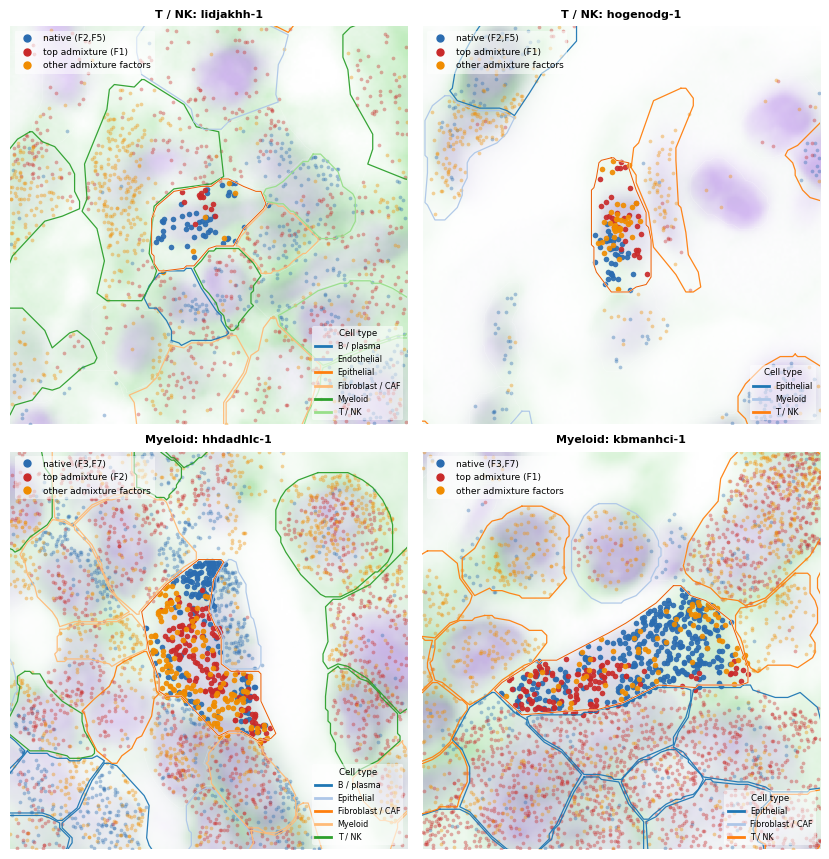

In [17]:

membrane_score.plot_examples(example_cells, score_annotation=score_annotation,
    cell_data=cell_spatial, ncol=2);


## Correction

The correction step applies all membrane-derived rules across annotated cell types and writes a corrected run. With the default multi-restart fit this is the molecule-vote ensemble correction: each restart member is scored independently, and a molecule is removed only when enough members agree.


In [18]:
correction = membrane_score.correct(rules=rules, name="membrane_clean_notebook")
correction.summary().head(12)


Ensemble correction over 10 members: molecules removed by >= 3 members (vote >= 0.30) are dropped (14,239,573 molecules).


,cell_type,n_cells,n_modified_cells,fraction_cells_modified,molecules_before,molecules_after,molecules_removed,fraction_molecules_removed,median_removed_per_modified_cell,median_fraction_removed_per_modified_cell
0,all,688099,411726,0.598353,82144903.0,67905330.0,14239573.0,0.173347,27.0,0.125364
1,B / plasma,25711,25242,0.981759,3831465.0,3224021.0,607444.0,0.158541,17.0,0.102564
2,Endothelial,18016,17848,0.990675,1275509.0,677674.0,597835.0,0.468703,27.0,0.478261
3,Epithelial,166396,166309,0.999477,50582711.0,42750224.0,7832487.0,0.154845,41.0,0.116740
4,Fibroblast / CAF,11279,11160,0.989449,851651.0,400294.0,451357.0,0.529979,37.0,0.645570
5,Myeloid,82470,81074,0.983073,9109012.0,5790325.0,3318687.0,0.364330,32.0,0.394615
6,T / NK,118803,110093,0.926685,8530598.0,7098835.0,1431763.0,0.167839,5.0,0.078431
7,unknown,265424,0,0.000000,7963957.0,7963957.0,0.0,0.000000,0.0,0.000000


The audit verifies the cleanup against the same exposure measurements: the
report gives per-pair sensitivity and the own-marker false-removal rate,
and the panels show the estimated admixture remaining and the pooled
exposure profile before and after cleanup.

The warnings are expected on this dataset: the thin, stain-weak types
(Endothelial, Fibroblast / CAF) receive no native factor from this
factorization, so rules targeting them over-remove genuine expression and
several pairs involving them remain uncovered. The [R membrane-scoring
tutorial](breast_5k_membrane_scoring.md) examines this limitation in
detail; the well-covered immune/epithelial pairs, which carry the largest
leakage flows, are cleaned effectively.

In [19]:
report = audit.evaluate(correction)
report.summary()

/tmp/ipykernel_3312794/346086481.py:1: UserWarning: Correction removed 52% of Fibroblast / CAF's own-marker molecules - severe over-removal of near-surely-genuine expression
  report = audit.evaluate(correction)
/tmp/ipykernel_3312794/346086481.py:1: UserWarning: Detected ~27,107 admixed molecules from B / plasma into Fibroblast / CAF, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_3312794/346086481.py:1: UserWarning: Detected ~224,819 admixed molecules from B / plasma into Myeloid, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_3312794/346086481.py:1: UserWarning: Detected ~888,042 admixed molecules from Endothelial into Epithelial, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_3312794/346086481.py:1: UserWarning: Detected ~62,750 admixed molecules from Endothelial into Myeloid, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp

{'detected_pairs': 29,
 'estimated_admixed_molecules': 10267159,
 'leakage_removed_overall': np.float64(0.7312333162001662),
 'median_pair_sensitivity': 0.9830171001028952,
 'own_marker_false_removal': 0.018572929773377773}

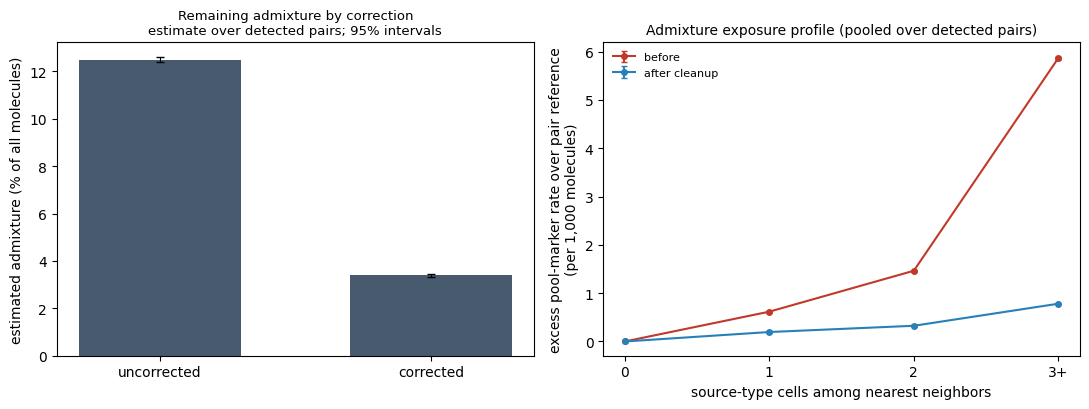

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
audit.plot_remaining({"corrected": correction}, ax=axes[0])
audit.plot_exposure(correction=correction, ax=axes[1])
fig.tight_layout()

The molecule-removal plot summarizes per-type removals alongside the aggregate row.


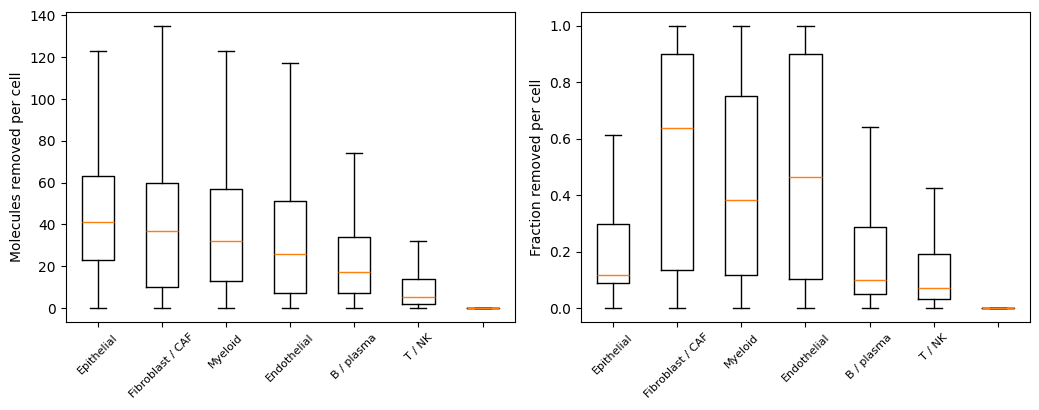

In [21]:
plot_molecule_removal(correction.cell_summary());

A compact cell-state diagnostic compares original and corrected cell-level expression neighborhoods on a 5,000-cell subset. The score is same-label kNN purity in PCA space, normalized against the label-frequency baseline. The cell QC thresholds (`min_molecules=30`, `min_genes=15`) match the R membrane-scoring tutorial; with the lower defaults, many small low-complexity segmented objects form detached UMAP islands on this 5K panel.

In [22]:
state_cells_max = 5000
original_state = ds.cell_state_umap(cells_max=state_cells_max,
    min_molecules=30, min_genes=15, num_threads=num_threads)
corrected_state = correction.cell_state_umap(annotation=annotation,
    cells_max=state_cells_max, min_molecules=30, min_genes=15,
    num_threads=num_threads)

state_scores = pd.DataFrame([
    annotation_knn_purity(original_state),
    annotation_knn_purity(corrected_state),
], index=["original", "corrected"])
state_scores

,knn_same_type_fraction,baseline_fraction,normalized_purity
original,0.817418,0.302157,0.738362
corrected,0.902011,0.325420,0.854740


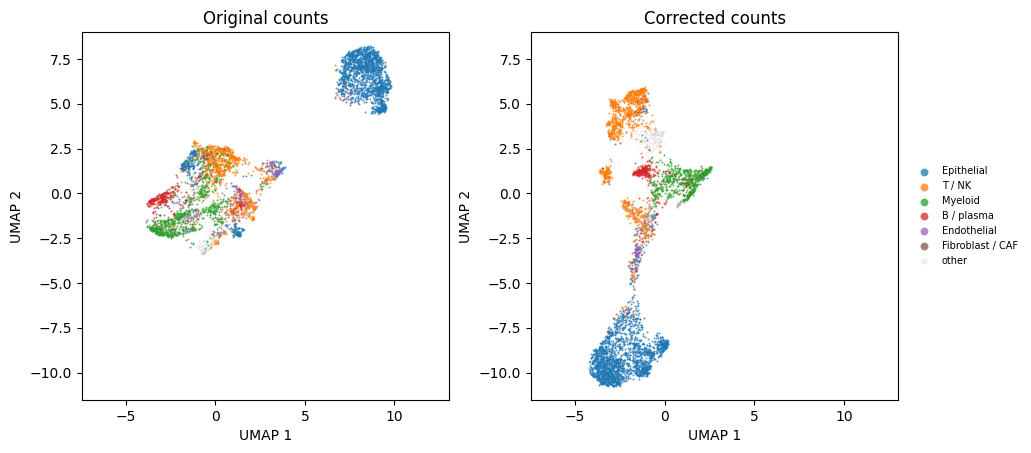

In [23]:
def state_umap_limits(*frames, pad_fraction=0.04):
    x = pd.concat([frame["umap_1"] for frame in frames]).to_numpy(dtype=float)
    y = pd.concat([frame["umap_2"] for frame in frames]).to_numpy(dtype=float)
    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y.min()), float(y.max())
    span = max(xmax - xmin, ymax - ymin)
    pad = span * pad_fraction
    xmid = (xmin + xmax) / 2
    ymid = (ymin + ymax) / 2
    half = span / 2 + pad
    return (xmid - half, xmid + half), (ymid - half, ymid + half)


def plot_state_umap(frame, title, ax, palette, xlim, ylim):
    labels_to_show = list(palette.keys())
    labels = frame["cell_type"].astype(str)
    for label, color in palette.items():
        mask = labels == label
        if mask.any():
            ax.scatter(frame.loc[mask, "umap_1"], frame.loc[mask, "umap_2"],
                s=2.0, alpha=0.75, linewidths=0, color=color, label=label, rasterized=True)
    other = ~labels.isin(labels_to_show)
    if other.any():
        ax.scatter(frame.loc[other, "umap_1"], frame.loc[other, "umap_2"],
            s=1.2, alpha=0.25, linewidths=0, color="#bdbdbd", label="other", rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")


state_labels = annotation.value_counts().head(10).index.tolist()
colors = plt.get_cmap("tab10")
palette = {label: colors(i) for i, label in enumerate(state_labels)}
xlim, ylim = state_umap_limits(original_state, corrected_state)
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.8), constrained_layout=True)
plot_state_umap(original_state, "Original counts", axes[0], palette, xlim, ylim)
plot_state_umap(corrected_state, "Corrected counts", axes[1], palette, xlim, ylim)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, markerscale=4, fontsize=7)
plt.show()
